# Dataset Exploration: `all_issues_with_pr_commit_comment_all_project_0922.pkl`

Comprehensive exploration of the MuLocBench dataset.

In [3]:
import os
os.chdir('..')  # run once, moves notebook's working directory to project root
print(os.getcwd())

/mnt/c/Users/afbla/Documents/Imperial/final_project


In [2]:
import pickle
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

with open('all_issues_with_pr_commit_comment_all_project_0922.pkl', 'rb') as f:
    issues = pickle.load(f)

print(f'Total issues: {len(issues)}')
print(f'Type: {type(issues)}')
print(f'Element type: {type(issues[0])}')

Total issues: 1100
Type: <class 'list'>
Element type: <class 'dict'>


## 1. Schema — what fields does each issue have?

In [3]:
# Collect all keys across all issues (some may be missing from a subset)
all_keys = collections.Counter(k for issue in issues for k in issue.keys())
print('Fields and how many issues contain them:')
for k, v in sorted(all_keys.items(), key=lambda x: -x[1]):
    pct = 100 * v / len(issues)
    print(f'  {k:<40} {v:>6}  ({pct:.1f}%)')

Fields and how many issues contain them:
  organization                               1100  (100.0%)
  repo_name                                  1100  (100.0%)
  base_commit                                1100  (100.0%)
  iss_html_url                               1100  (100.0%)
  iss_label                                  1100  (100.0%)
  title                                      1100  (100.0%)
  body                                       1100  (100.0%)
  pr_html_url                                1100  (100.0%)
  commit_html_url                            1100  (100.0%)
  file_loc                                   1100  (100.0%)
  own_code_loc                               1100  (100.0%)
  ass_file_loc                               1100  (100.0%)
  other_rep_loc                              1100  (100.0%)
  analysis                                   1100  (100.0%)
  loctype                                    1100  (100.0%)
  iss_has_pr                                  649  (59.0%)


In [4]:
# Inspect one full issue to understand value types
sample = issues[0]
print(f'Sample issue from repo: {sample.get("repo_name")}')
print()
for k, v in sample.items():
    val_repr = repr(v)
    if len(val_repr) > 200:
        val_repr = val_repr[:200] + '...'
    print(f'[{k}]  type={type(v).__name__}')
    print(f'  {val_repr}')
    print()

Sample issue from repo: scikit-learn

[organization]  type=str
  'scikit-learn'

[repo_name]  type=str
  'scikit-learn'

[base_commit]  type=str
  '559609fe98ec2145788133687e64a6e87766bc77'

[iss_html_url]  type=str
  'https://github.com/scikit-learn/scikit-learn/issues/25525'

[iss_label]  type=str
  'Bug\nmodule:feature_extraction'

[title]  type=str
  'Extend SequentialFeatureSelector example to demonstrate how to use negative tol'

[body]  type=str
  '### Describe the bug\r\n\r\nI utilized the **SequentialFeatureSelector** for feature selection in my code, with the direction set to "backward." The tolerance value is negative and the selection proc...

[code]  type=NoneType
  None

[pr_html_url]  type=str
  'https://github.com/scikit-learn/scikit-learn/pull/26205'

[commit_html_url]  type=NoneType
  None

[file_loc]  type=dict
  {'base_commit': '559609fe98ec2145788133687e64a6e87766bc77', 'files': [{'path': 'examples/feature_selection/plot_select_from_model_diabetes.py', 'status': 'm

## 2. Repository distribution

In [3]:
repo_counts = collections.Counter(i.get('repo_name') for i in issues)
repo_df = pd.DataFrame(repo_counts.most_common(), columns=['repo', 'count'])
print(repo_df.to_string(index=False))

                   repo  count
                 pandas     64
           scikit-learn     58
                 scrapy     51
                ansible     48
                 yt-dlp     47
             localstack     46
           transformers     44
                 yolov5     44
           gpt-engineer     38
Real-Time-Voice-Cloning     32
                MetaGPT     32
               faceswap     30
                  keras     28
              OpenHands     28
               requests     26
                   core     26
                thefuck     26
           gpt_academic     26
                  flask     25
  text-generation-webui     25
                fastapi     24
                  manim     23
            private-gpt     22
 stable-diffusion-webui     18
               gpt4free     18
                AutoGPT     16
                   rich     16
               langflow     16
               sherlock     16
     screenshot-to-code     15
                cpython     15
       f

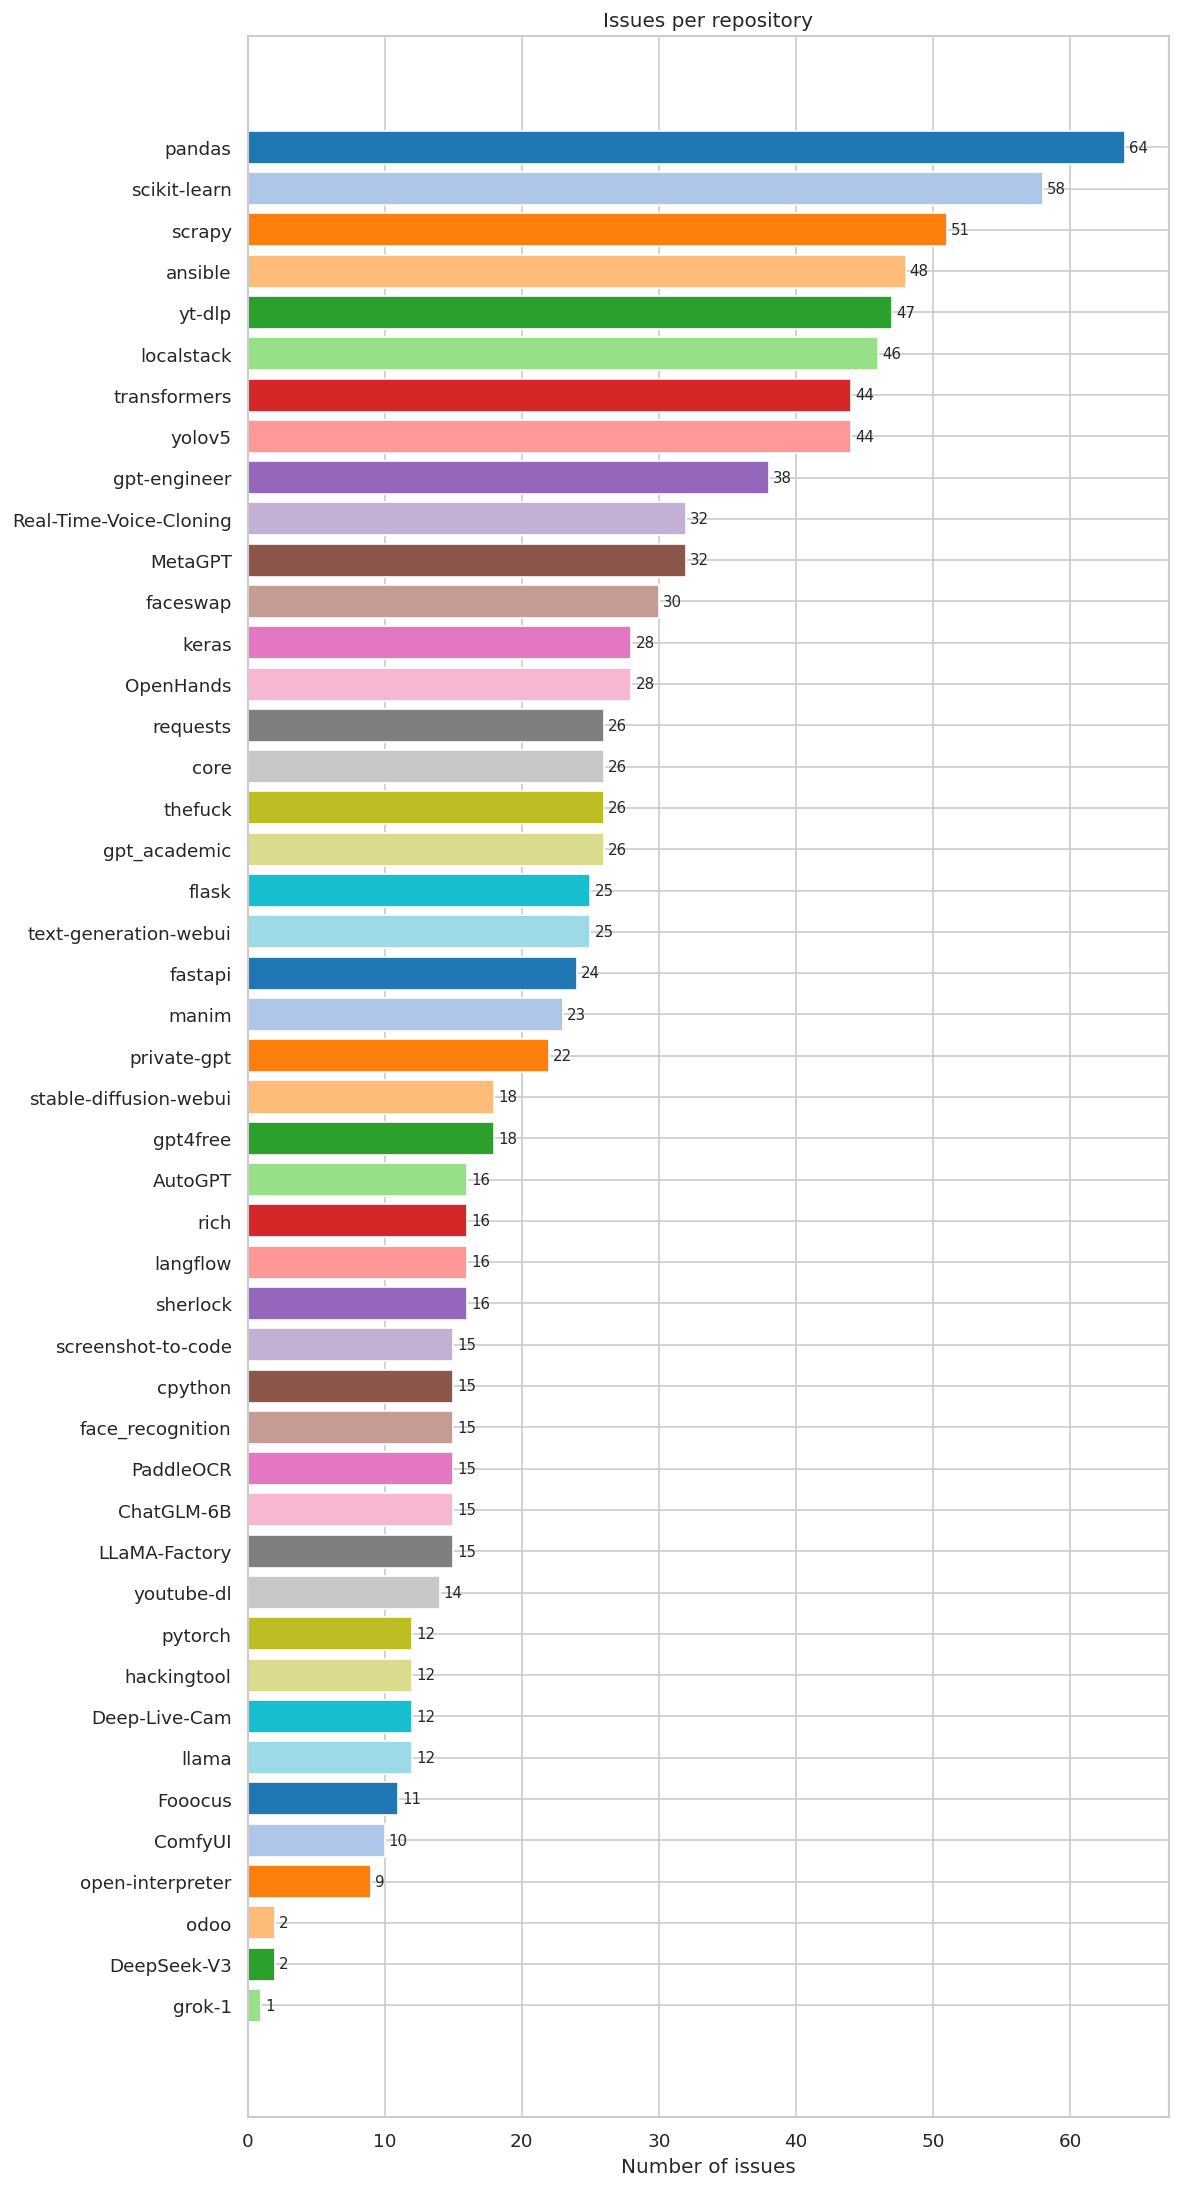

In [6]:
fig, ax = plt.subplots(figsize=(10, max(4, len(repo_df) * 0.4)))
ax.barh(repo_df['repo'][::-1], repo_df['count'][::-1], color=sns.color_palette('tab20', len(repo_df))[::-1])
ax.set_xlabel('Number of issues')
ax.set_title('Issues per repository')
for bar, val in zip(ax.patches, repo_df['count'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Convert to DataFrame for easier analysis

In [4]:
df = pd.DataFrame(issues)
print(f'Shape: {df.shape}')
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Null counts:')
print(df.isnull().sum())

Shape: (1100, 17)

Dtypes:
organization           str
repo_name              str
base_commit            str
iss_html_url           str
iss_label              str
title                  str
body                   str
code               float64
pr_html_url            str
commit_html_url        str
file_loc            object
own_code_loc        object
ass_file_loc        object
other_rep_loc       object
analysis            object
loctype             object
iss_has_pr         float64
dtype: object

Null counts:
organization          0
repo_name             0
base_commit           0
iss_html_url          0
iss_label             0
title                 0
body                  6
code               1100
pr_html_url         384
commit_html_url    1037
file_loc              0
own_code_loc          0
ass_file_loc          0
other_rep_loc         0
analysis              0
loctype               0
iss_has_pr          451
dtype: int64


In [8]:
df.head(3)

,organization,repo_name,base_commit,iss_html_url,iss_label,title,body,code,pr_html_url,commit_html_url,file_loc,own_code_loc,ass_file_loc,other_rep_loc,analysis,loctype,iss_has_pr
0,scikit-learn,scikit-learn,559609fe98ec2145788133687e64a6e87766bc77,https://github.com/scikit-learn/scikit-learn/i...,Bug\nmodule:feature_extraction,Extend SequentialFeatureSelector example to de...,### Describe the bug\r\n\r\nI utilized the **S...,NaN,https://github.com/scikit-learn/scikit-learn/p...,NaN,{'base_commit': '559609fe98ec2145788133687e64a...,[],[],[],"{'iss_type': '1', 'iss_reason': '1', 'loc_way'...",{'code': ['examples/feature_selection/plot_sel...,NaN
1,pallets,flask,cb94f4c5d3d4e1797207fd03d20d06c7bc0d05b4,https://github.com/pallets/flask/issues/2264,cli,Handle app factory in FLASK_APP,`FLASK_APP=myproject.app:create_app('dev')`\r\...,NaN,https://github.com/pallets/flask/pull/2326,NaN,{'base_commit': 'cb94f4c5d3d4e1797207fd03d20d0...,[],[],[],"{'iss_type': '4', 'iss_reason': '2', 'loc_way'...","{'code': ['flask/cli.py'], 'doc': [], 'test': ...",1.0
2,localstack,localstack,737ca72b7bce6e377dd6876eacee63338fa8c30c,https://github.com/localstack/localstack/issue...,,ERROR:localstack.services.generic_proxy: Error...,Starting local dev environment. CTRL-C to quit...,NaN,https://github.com/localstack/localstack/pull/...,NaN,{'base_commit': '737ca72b7bce6e377dd6876eacee6...,[],[],[],"{'iss_type': '1', 'iss_reason': '2', 'loc_way'...","{'code': ['localstack/config.py', 'localstack/...",1.0


## 4. Text fields — titles, bodies, comments

In [9]:
# Identify text-like columns (string type)
text_cols = [c for c in df.columns if df[c].dtype == object]
print('Object-type columns:', text_cols)

# For string columns compute length stats
for col in text_cols:
    sample_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
    if isinstance(sample_val, str):
        lengths = df[col].dropna().str.len()
        print(f'\n[{col}]  non-null={lengths.count()}')
        print(f'  mean={lengths.mean():.0f}  median={lengths.median():.0f}  max={lengths.max()}')

Object-type columns: ['file_loc', 'own_code_loc', 'ass_file_loc', 'other_rep_loc', 'analysis', 'loctype']


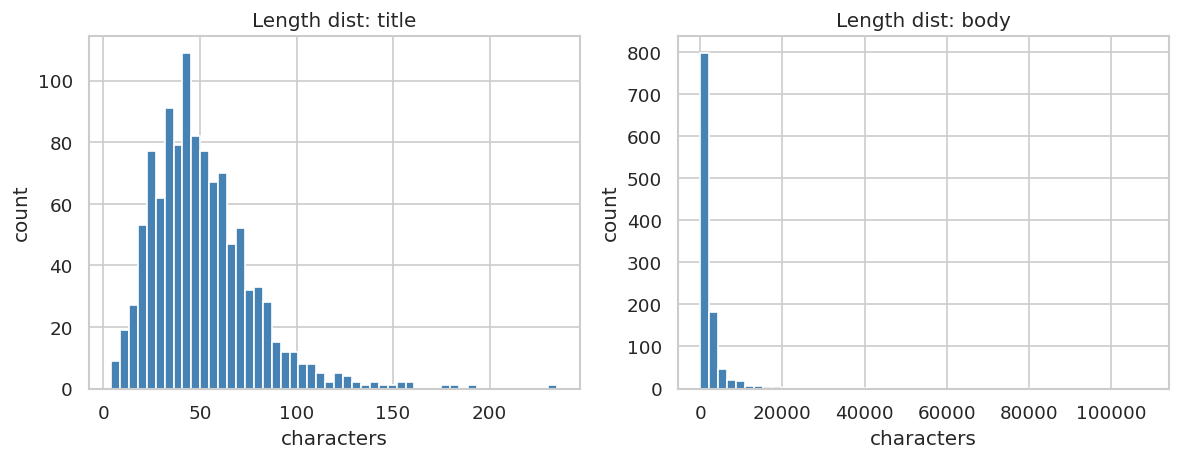

In [10]:
str_cols = ['title', 'body']

fig, axes = plt.subplots(1, len(str_cols), figsize=(5 * len(str_cols), 4))
for ax, col in zip(axes, str_cols):
    lengths = df[col].dropna().str.len()
    ax.hist(lengths, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'Length dist: {col}')
    ax.set_xlabel('characters')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 5. List / nested fields (PRs, commits, comments)

In [11]:
# Identify columns that contain lists
list_cols = []
for col in df.columns:
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
    if isinstance(sample, list):
        list_cols.append(col)

print('List-type columns:', list_cols)

for col in list_cols:
    lengths = df[col].dropna().apply(len)
    print(f'\n[{col}]')
    print(f'  non-null={lengths.count()}  mean={lengths.mean():.2f}  median={lengths.median():.1f}  max={lengths.max()}')
    print(f'  issues with 0 items: {(lengths == 0).sum()}')
    print(f'  issues with >=1 item: {(lengths >= 1).sum()}')

List-type columns: ['own_code_loc', 'ass_file_loc', 'other_rep_loc']

[own_code_loc]
  non-null=1100  mean=0.03  median=0.0  max=1
  issues with 0 items: 1067
  issues with >=1 item: 33

[ass_file_loc]
  non-null=1100  mean=0.03  median=0.0  max=2
  issues with 0 items: 1076
  issues with >=1 item: 24

[other_rep_loc]
  non-null=1100  mean=0.02  median=0.0  max=2
  issues with 0 items: 1077
  issues with >=1 item: 23


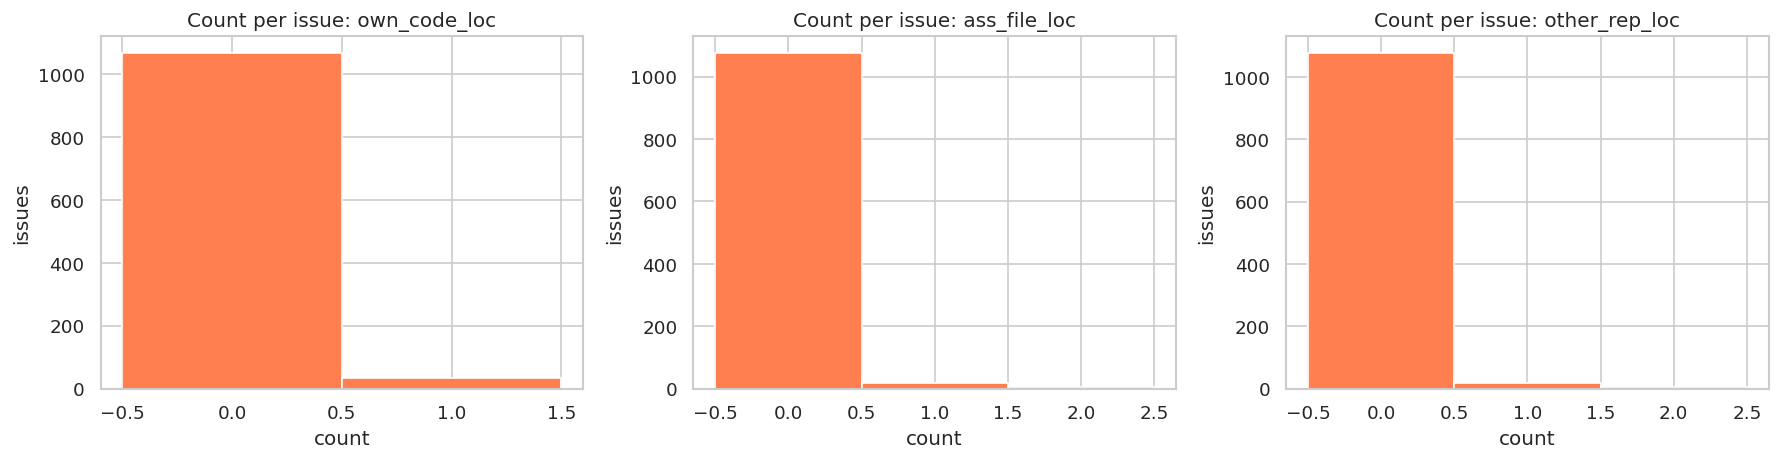

In [12]:
# Distributions for list-length columns
if list_cols:
    fig, axes = plt.subplots(1, len(list_cols), figsize=(5 * len(list_cols), 4))
    if len(list_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, list_cols):
        lengths = df[col].dropna().apply(len)
        max_val = min(lengths.max(), 30)  # cap for readability
        ax.hist(lengths.clip(upper=max_val), bins=range(0, int(max_val) + 2), color='coral', edgecolor='white', align='left')
        ax.set_title(f'Count per issue: {col}')
        ax.set_xlabel('count')
        ax.set_ylabel('issues')
        if lengths.max() > max_val:
            ax.set_xlabel(f'count (capped at {max_val})')
    plt.tight_layout()
    plt.show()

In [13]:
# Inspect schema of first element inside each list column
for col in list_cols:
    non_empty = df[col].dropna().apply(lambda x: x if len(x) > 0 else None).dropna()
    if non_empty.empty:
        continue
    first_item = non_empty.iloc[0][0]
    print(f'\n=== {col} — first item ===')
    if isinstance(first_item, dict):
        for k, v in first_item.items():
            print(f'  {k}: {repr(v)[:120]}')
    else:
        print(repr(first_item)[:300])


=== own_code_loc — first item ===
  Loc: [7]
  path: None

=== ass_file_loc — first item ===
'frontend/node_modules'

=== other_rep_loc — first item ===
  org: 'ohmyzsh'
  pro: 'ohmyzsh'
  path: ['plugins/thefuck']


## 6. Numeric / ID fields

In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', num_cols)
if num_cols:
    display(df[num_cols].describe())

Numeric columns: ['code', 'iss_has_pr']


,code,iss_has_pr
count,0.0,649.0
mean,NaN,1.0
std,NaN,0.0
min,NaN,1.0
25%,NaN,1.0
50%,NaN,1.0
75%,NaN,1.0
max,NaN,1.0


## 7. Bug localization fields — files, functions, lines

In [15]:
# Look for fields that seem related to bug location
loc_keywords = ['file', 'func', 'line', 'loc', 'patch', 'diff', 'hunk', 'change', 'modified', 'buggy', 'fix']
loc_cols = [c for c in df.columns if any(kw in c.lower() for kw in loc_keywords)]
print('Potential localization columns:', loc_cols)

for col in loc_cols:
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
    print(f'\n[{col}]  type={type(sample).__name__}')
    print(f'  non-null: {df[col].notna().sum()}')
    if isinstance(sample, (list, dict)):
        print(f'  sample: {repr(sample)[:300]}')
    elif isinstance(sample, str):
        print(f'  sample: {sample[:300]}')

Potential localization columns: ['file_loc', 'own_code_loc', 'ass_file_loc', 'other_rep_loc', 'loctype']

[file_loc]  type=dict
  non-null: 1100
  sample: {'base_commit': '559609fe98ec2145788133687e64a6e87766bc77', 'files': [{'path': 'examples/feature_selection/plot_select_from_model_diabetes.py', 'status': 'modified', 'Loc': {(None, None, None): {'add': [145], 'mod': [123, 124, 125]}}}]}

[own_code_loc]  type=list
  non-null: 1100
  sample: []

[ass_file_loc]  type=list
  non-null: 1100
  sample: []

[other_rep_loc]  type=list
  non-null: 1100
  sample: []

[loctype]  type=dict
  non-null: 1100
  sample: {'code': ['examples/feature_selection/plot_select_from_model_diabetes.py'], 'doc': [], 'test': [], 'config': [], 'asset': []}


In [16]:
# If there's a file-count field, show distribution per repo
for col in loc_cols:
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
    if isinstance(sample, list):
        df[f'_n_{col}'] = df[col].apply(lambda x: len(x) if isinstance(x, list) else np.nan)
        print(f'\nFiles/items in [{col}] by repo:')
        print(df.groupby('repo_name')[f'_n_{col}'].describe().round(2))


Files/items in [own_code_loc] by repo:
                         count  mean   std  min  25%  50%  75%  max
repo_name                                                          
AutoGPT                   16.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
ChatGLM-6B                15.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
ComfyUI                   10.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
Deep-Live-Cam             12.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
DeepSeek-V3                2.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
Fooocus                   11.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
LLaMA-Factory             15.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
MetaGPT                   32.0  0.06  0.25  0.0  0.0  0.0  0.0  1.0
OpenHands                 28.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
PaddleOCR                 15.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
Real-Time-Voice-Cloning   32.0  0.00  0.00  0.0  0.0  0.0  0.0  0.0
ansible                   48.0  0.08  0.28  0.0  0.0  0.0  0.0  1.0
core    

## 8. Cross-field analysis — PRs, commits, comments linkage

In [17]:
# Check which list columns (PR/commit/comment) each issue has non-empty
if list_cols:
    presence = pd.DataFrame({
        col: df[col].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
        for col in list_cols
    })
    print('Co-occurrence of list fields (True = at least one item):')
    display(presence.groupby(list_cols).size().reset_index(name='count').sort_values('count', ascending=False))

Co-occurrence of list fields (True = at least one item):


,own_code_loc,ass_file_loc,other_rep_loc,count
0,False,False,False,1020
3,True,False,False,33
2,False,True,False,24
1,False,False,True,23


In [18]:
# Per-repo breakdown of list field availability
if list_cols:
    for col in list_cols:
        has_col = df[col].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
        summary = df.groupby('repo_name').apply(lambda g: has_col.loc[g.index].sum()).rename(col)
        print(f'\nIssues with >=1 [{col}] per repo:')
        print(summary.to_frame().join(repo_df.set_index('repo')))


Issues with >=1 [own_code_loc] per repo:
                         own_code_loc  count
repo_name                                   
AutoGPT                             0     16
ChatGLM-6B                          0     15
ComfyUI                             0     10
Deep-Live-Cam                       0     12
DeepSeek-V3                         0      2
Fooocus                             0     11
LLaMA-Factory                       0     15
MetaGPT                             2     32
OpenHands                           0     28
PaddleOCR                           0     15
Real-Time-Voice-Cloning             0     32
ansible                             4     48
core                                0     26
cpython                             0     15
face_recognition                    3     15
faceswap                            0     30
fastapi                             4     24
flask                               1     25
gpt-engineer                        0     38
gpt4free     

## 9. Sample issue — full deep-dive

In [19]:
# Show a complete issue — pick one with rich data (has PR and commits)
rich = df.copy()
for col in list_cols:
    rich = rich[rich[col].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]

if rich.empty:
    rich = df

sample_issue = rich.iloc[0].to_dict()
print(f"Repo: {sample_issue.get('repo_name')}")
print(f"Title: {sample_issue.get('title')}")
print()
for k, v in sample_issue.items():
    if k.startswith('_n_'):
        continue
    print(f'--- {k} ---')
    if isinstance(v, list):
        print(f'  ({len(v)} items)')
        for item in v[:2]:  # show first 2
            if isinstance(item, dict):
                for ik, iv in item.items():
                    print(f'    {ik}: {repr(iv)[:150]}')
            else:
                print(f'  {repr(item)[:200]}')
            print()
    elif isinstance(v, str):
        print(v[:500])
    else:
        print(repr(v)[:300])
    print()

Repo: scikit-learn
Title: Extend SequentialFeatureSelector example to demonstrate how to use negative tol

--- organization ---
scikit-learn

--- repo_name ---
scikit-learn

--- base_commit ---
559609fe98ec2145788133687e64a6e87766bc77

--- iss_html_url ---
https://github.com/scikit-learn/scikit-learn/issues/25525

--- iss_label ---
Bug
module:feature_extraction

--- title ---
Extend SequentialFeatureSelector example to demonstrate how to use negative tol

--- body ---
### Describe the bug

I utilized the **SequentialFeatureSelector** for feature selection in my code, with the direction set to "backward." The tolerance value is negative and the selection process stops when the decrease in the metric, AUC in this case, is less than the specified tolerance. Generally, increasing the number of features results in a higher AUC, but sacrificing some features, especially correlated ones that offer little contribution, can produce a pessimistic model with a lower A

--- code ---
nan

--- pr_ht

## 10. Summary statistics

In [20]:
print('=== Dataset Summary ===')
print(f'Total issues:       {len(df)}')
print(f'Unique repos:       {df["repo_name"].nunique()}')
print(f'Total fields/cols:  {len(df.columns)}')
print()
for col in list_cols:
    counts = df[col].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print(f'Total {col}: {counts.sum():.0f}  (avg {counts.mean():.2f}/issue)')

print()
str_col_candidates = [c for c in df.columns if df[c].dtype == object and isinstance(df[c].dropna().iloc[0] if not df[c].dropna().empty else None, str)]
for col in str_col_candidates:
    total_chars = df[col].dropna().str.len().sum()
    print(f'Total chars in [{col}]: {total_chars:,}')

=== Dataset Summary ===
Total issues:       1100
Unique repos:       46
Total fields/cols:  20

Total own_code_loc: 33  (avg 0.03/issue)
Total ass_file_loc: 29  (avg 0.03/issue)
Total other_rep_loc: 27  (avg 0.02/issue)



In [51]:
loc_data = {k: v for k, v in loc_data.items() if v is not None and v != 0}

with open('loc_data.json', 'w') as f:
    json.dump(loc_data, f)

print(f'Remaining: {len(loc_data)} repos counted')
print(loc_data)

Remaining: 45 repos counted
{'flask': 14081, 'requests': 9818, 'gpt-engineer': 9442, 'stable-diffusion-webui': 34008, 'screenshot-to-code': 9930, 'yt-dlp': 230198, 'Real-Time-Voice-Cloning': 5291, 'keras': 273067, 'scrapy': 61558, 'manim': 20467, 'text-generation-webui': 21582, 'thefuck': 12743, 'faceswap': 80858, 'MetaGPT': 73324, 'yolov5': 15240, 'face_recognition': 2273, 'rich': 45787, 'langflow': 1199, 'scikit-learn': 369160, 'localstack': 450483, 'transformers': 1366982, 'pandas': 559600, 'private-gpt': 93003, 'AutoGPT': 374307, 'fastapi': 93259, 'ansible': 213536, 'OpenHands': 163968, 'cpython': 959279, 'sherlock': 1796, 'grok-1': 1972, 'pytorch': 2174201, 'hackingtool': 4182, 'open-interpreter': 16285, 'gpt4free': 50451, 'ComfyUI': 188409, 'Fooocus': 43537, 'gpt_academic': 53558, 'odoo': 1032369, 'Deep-Live-Cam': 6590, 'youtube-dl': 150327, 'PaddleOCR': 98917, 'ChatGLM-6B': 4693, 'llama': 985, 'LLaMA-Factory': 46418, 'DeepSeek-V3': 1204}


In [52]:
import subprocess
import os

for repo in repos:
    path = f'repos/{repo}'
    if not os.path.exists(path) or not os.listdir(path):
        org = org_map[repo]
        url = f'https://github.com/{org}/{repo}'
        print(f'Cloning {repo}...')
        subprocess.run(['git', 'clone', '--depth=1', url, path], capture_output=True)
        print(f'{repo}: done')
    else:
        print(f'{repo}: already cloned')

scikit-learn: already cloned
flask: already cloned
localstack: already cloned
transformers: already cloned
pandas: already cloned
private-gpt: already cloned
requests: already cloned
gpt-engineer: already cloned
stable-diffusion-webui: already cloned
core: already cloned
screenshot-to-code: already cloned
AutoGPT: already cloned
yt-dlp: already cloned
Real-Time-Voice-Cloning: already cloned
keras: already cloned
scrapy: already cloned
fastapi: already cloned
manim: already cloned
ansible: already cloned
text-generation-webui: already cloned
thefuck: already cloned
OpenHands: already cloned
faceswap: already cloned
cpython: already cloned
MetaGPT: already cloned
yolov5: already cloned
face_recognition: already cloned
rich: already cloned
langflow: already cloned
sherlock: already cloned
grok-1: already cloned
pytorch: already cloned
hackingtool: already cloned
open-interpreter: already cloned
gpt4free: already cloned
ComfyUI: already cloned
Fooocus: already cloned
gpt_academic: already 

In [37]:
import adjustText

issue_counts = df['repo_name'].value_counts()
loc_series = pd.Series(loc_data)
plot_df = pd.DataFrame({'issues': issue_counts, 'loc': loc_series}).dropna()
plot_df = plot_df[plot_df['loc'] > 0]

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(plot_df['loc'], plot_df['issues'], color='steelblue', zorder=5)

texts = [
    ax.text(row['loc'], row['issues'], repo, fontsize=7)
    for repo, row in plot_df.iterrows()
]

adjustText.adjust_text(
    texts,
    x=plot_df['loc'].values,
    y=plot_df['issues'].values,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_points=(1.5, 1.5),
    force_points=(0.1, 0.1),
    lim=50  # max iterations — default is 500
)

ax.set_xscale('log')
ax.set_xlabel('Lines of Code (log scale)')
ax.set_ylabel('Number of Issues')
ax.set_title('Issues vs Codebase Size (MULocBench)')
plt.tight_layout()
plt.savefig('loc_vs_issues.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3680/53788111.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


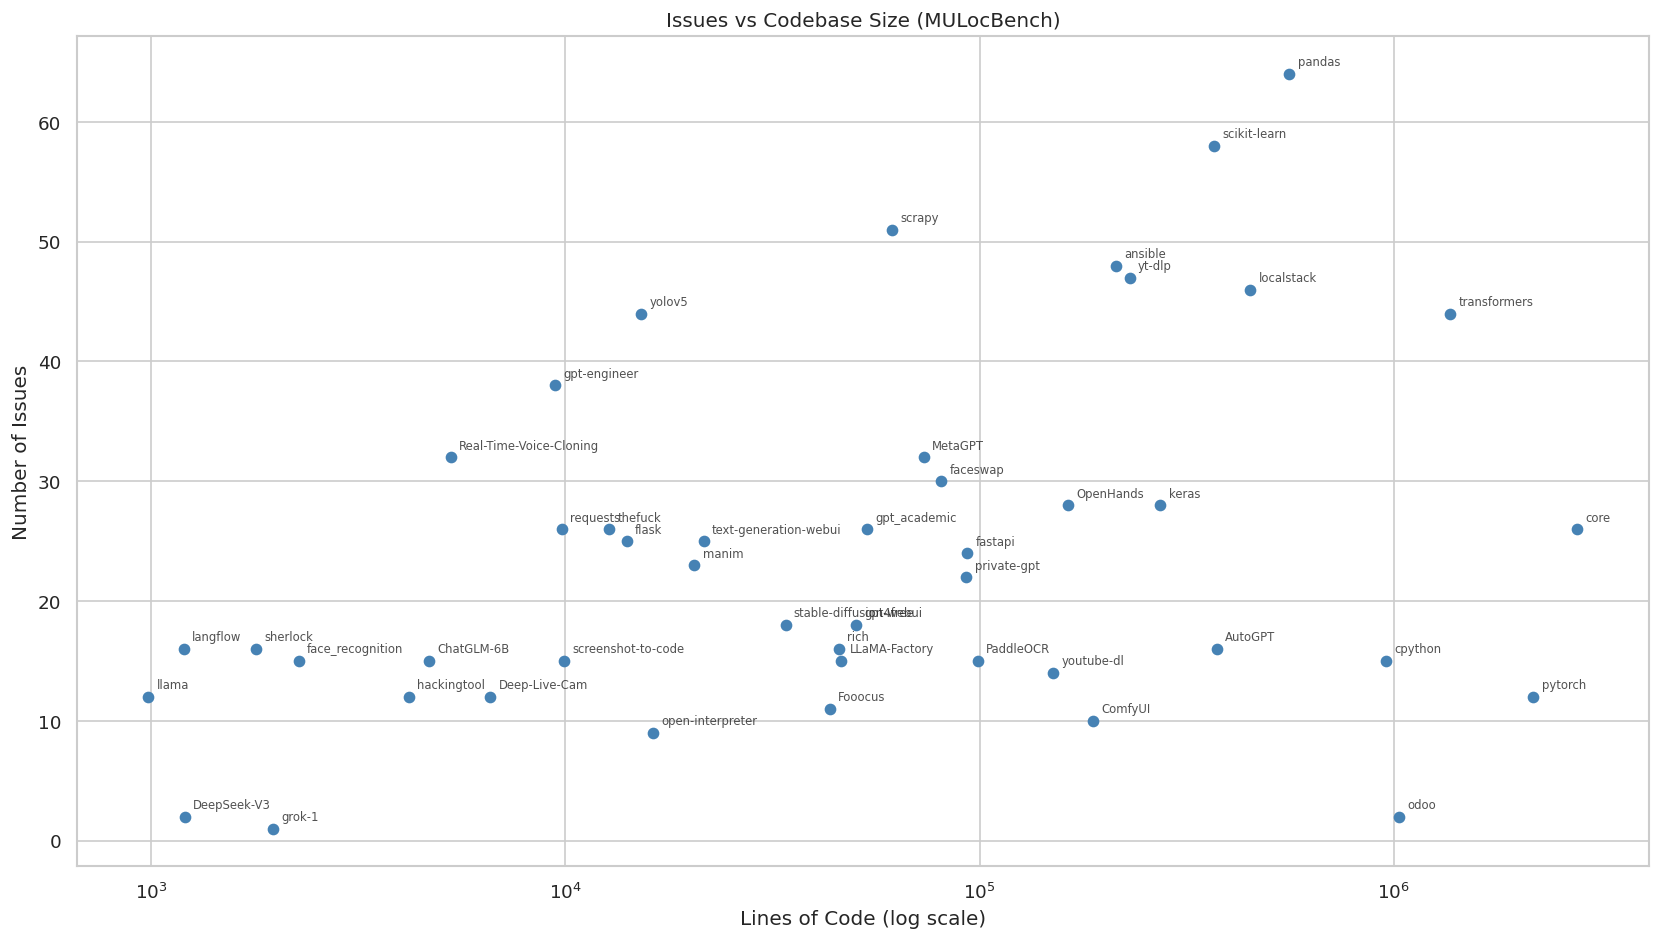

In [56]:
%matplotlib inline
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('loc_data.json', 'r') as f:
    loc_data = json.load(f)

issue_counts = df['repo_name'].value_counts()
loc_series = pd.Series(loc_data)
plot_df = pd.DataFrame({'issues': issue_counts, 'loc': loc_series}).dropna()
plot_df = plot_df[plot_df['loc'] > 0]

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(plot_df['loc'], plot_df['issues'], color='steelblue')

for repo, row in plot_df.iterrows():
    ax.annotate(repo, (row['loc'], row['issues']),
                textcoords='offset points', xytext=(5, 5),
                fontsize=7, alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('Lines of Code (log scale)')
ax.set_ylabel('Number of Issues')
ax.set_title('Issues vs Codebase Size (MULocBench)')
plt.tight_layout()
plt.show()

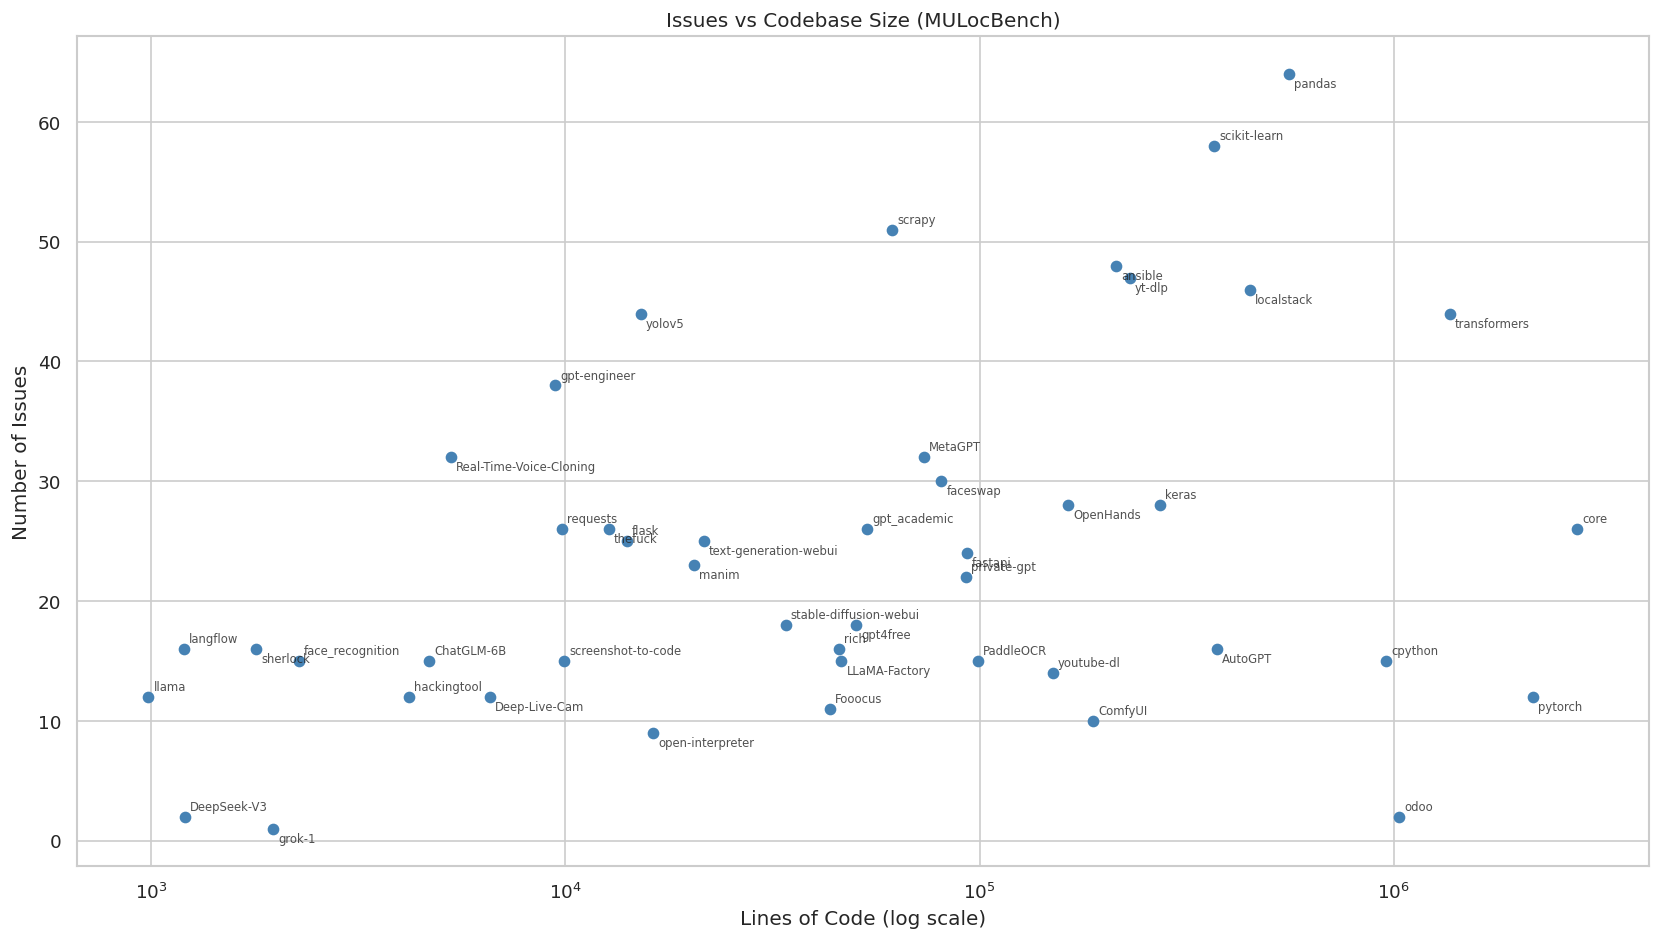

In [57]:
%matplotlib inline
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('loc_data.json', 'r') as f:
    loc_data = json.load(f)

issue_counts = df['repo_name'].value_counts()
loc_series = pd.Series(loc_data)
plot_df = pd.DataFrame({'issues': issue_counts, 'loc': loc_series}).dropna()
plot_df = plot_df[plot_df['loc'] > 0]

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(plot_df['loc'], plot_df['issues'], color='steelblue')

for repo, row in plot_df.iterrows():
    x, y = row['loc'], row['issues']
    # alternate labels above and below to reduce overlap
    offset = 4 if hash(repo) % 2 == 0 else -8
    ax.annotate(repo, (x, y),
                textcoords='offset points', xytext=(3, offset),
                fontsize=7, alpha=0.8)
    
ax.set_xscale('log')
ax.set_xlabel('Lines of Code (log scale)')
ax.set_ylabel('Number of Issues')
ax.set_title('Issues vs Codebase Size (MULocBench)')
plt.tight_layout()
plt.show()

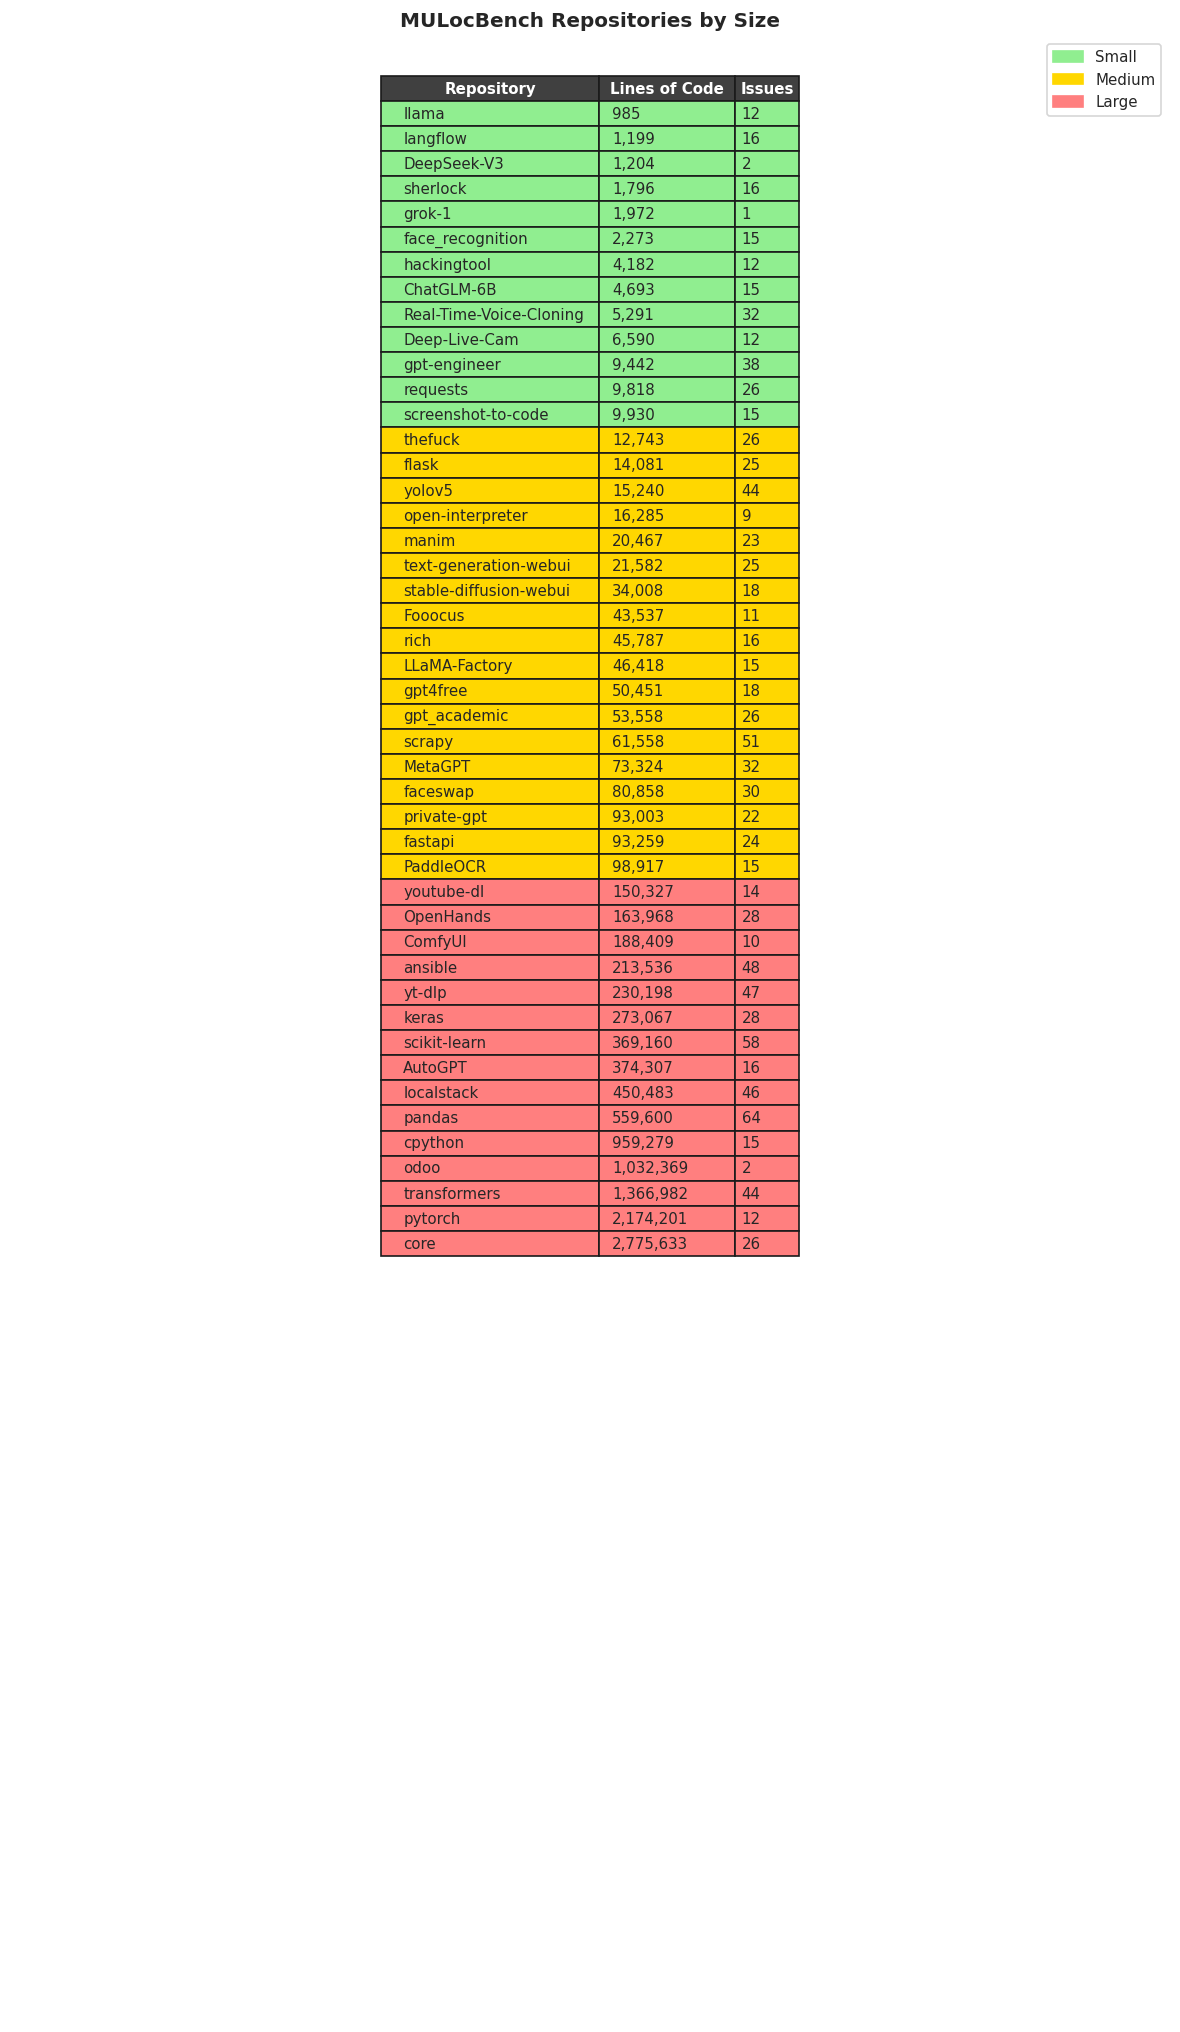

In [58]:
%matplotlib inline
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

with open('loc_data.json', 'r') as f:
    loc_data = json.load(f)

issue_counts = df['repo_name'].value_counts()
loc_series = pd.Series(loc_data)
plot_df = pd.DataFrame({'issues': issue_counts, 'lines': loc_series}).dropna()
plot_df = plot_df[plot_df['lines'] > 0].sort_values(['lines', 'issues'])

def bucket(lines):
    if lines < 10000:
        return 'small'
    elif lines < 100000:
        return 'medium'
    else:
        return 'large'

plot_df['size'] = plot_df['lines'].apply(bucket)

color_map = {'small': '#90EE90', 'medium': '#FFD700', 'large': '#FF7F7F'}

nrows = len(plot_df)
fig, ax = plt.subplots(figsize=(10, nrows * 0.35 + 1))
ax.axis('off')

table_data = [[repo, f'{int(row.lines):,}', int(row.issues)]
              for repo, row in plot_df.iterrows()]
col_labels = ['Repository', 'Lines of Code', 'Issues']

table = ax.table(cellText=table_data, colLabels=col_labels,
                 loc='upper center', cellLoc='left')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width([0, 1, 2])

for i, (repo, row) in enumerate(plot_df.iterrows()):
    colour = color_map[row['size']]
    for j in range(3):
        table[i+1, j].set_facecolor(colour)

for j in range(3):
    table[0, j].set_facecolor('#404040')
    table[0, j].set_text_props(color='white', fontweight='bold')

patches = [mpatches.Patch(color=color_map[s], label=s.capitalize())
           for s in ['small', 'medium', 'large']]
ax.legend(handles=patches, bbox_to_anchor=(1, 1), loc='upper right', fontsize=9)

plt.title('MULocBench Repositories by Size', fontweight='bold')
plt.tight_layout()
fig.savefig('repo_size_table.png', dpi=150, bbox_inches='tight', pad_inches=0.2)
plt.show()

In [59]:
from collections import defaultdict

CODE_EXTENSIONS = {
    '.py', '.js', '.ts', '.jsx', '.tsx',
    '.java', '.c', '.cpp', '.h', '.cs',
    '.go', '.rs', '.rb', '.php',
    '.sh', '.bash',
    '.html', '.css', '.scss',
    '.sql', '.yaml', '.yml', '.toml', '.ini', '.cfg',
}

EXCLUDE_DIRS = {
    '.git', '__pycache__', 'node_modules', 'venv', '.venv',
    'env', 'dist', 'build', '.eggs',
}

def count_loc_by_language(path):
    counts = defaultdict(int)
    for root, dirs, files in os.walk(path):
        dirs[:] = [d for d in dirs if d not in EXCLUDE_DIRS and not d.startswith('.')]
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in CODE_EXTENSIONS:
                try:
                    with open(os.path.join(root, file), 'r', errors='ignore') as f:
                        lines = sum(1 for line in f if line.strip())
                    counts[ext] += lines
                except:
                    pass
    return dict(counts)

# test on flask first
result = count_loc_by_language('repos/flask')
for ext, count in sorted(result.items(), key=lambda x: -x[1]):
    print(f'{ext}: {count:,}')
print(f'Total: {sum(result.values()):,}')

.py: 14,081
.html: 326
.toml: 321
.css: 110
.yaml: 33
.sql: 24
Total: 14,895


In [60]:
import os
import json
from collections import defaultdict

CODE_EXTENSIONS = {
    '.py', '.js', '.ts', '.jsx', '.tsx',
    '.java', '.c', '.cpp', '.h', '.cs',
    '.go', '.rs', '.rb', '.php',
    '.sh', '.bash',
    '.html', '.css', '.scss',
    '.sql', '.yaml', '.yml', '.toml', '.ini', '.cfg',
}

EXCLUDE_DIRS = {
    '.git', '__pycache__', 'node_modules', 'venv', '.venv',
    'env', 'dist', 'build', '.eggs',
}

def count_loc_by_language(path):
    counts = defaultdict(int)
    for root, dirs, files in os.walk(path):
        dirs[:] = [d for d in dirs if d not in EXCLUDE_DIRS and not d.startswith('.')]
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in CODE_EXTENSIONS:
                try:
                    with open(os.path.join(root, file), 'r', errors='ignore') as f:
                        lines = sum(1 for line in f if line.strip())
                    counts[ext] += lines
                except:
                    pass
    return dict(counts)

loc_by_language = {}

for repo in repos:
    path = f'repos/{repo}'
    if not os.path.exists(path) or not os.listdir(path):
        print(f'{repo}: not cloned — skipping')
        continue
    print(f'Counting {repo}...')
    loc_by_language[repo] = count_loc_by_language(path)
    print(f'{repo}: {sum(loc_by_language[repo].values()):,} total')

with open('loc_by_language.json', 'w') as f:
    json.dump(loc_by_language, f, indent=2)

print('Done — saved to loc_by_language.json')

Counting scikit-learn...
scikit-learn: 380,305 total
Counting flask...
flask: 14,895 total
Counting localstack...
localstack: 469,538 total
Counting transformers...
transformers: 1,372,123 total
Counting pandas...
pandas: 581,441 total
Counting private-gpt...
private-gpt: 105,585 total
Counting requests...
requests: 10,021 total
Counting gpt-engineer...
gpt-engineer: 9,691 total
Counting stable-diffusion-webui...
stable-diffusion-webui: 40,917 total
Counting core...
core: 2,831,311 total
Counting screenshot-to-code...
screenshot-to-code: 29,111 total
Counting AutoGPT...
AutoGPT: 579,724 total
Counting yt-dlp...
yt-dlp: 231,307 total
Counting Real-Time-Voice-Cloning...
Real-Time-Voice-Cloning: 5,346 total
Counting keras...
keras: 274,840 total
Counting scrapy...
scrapy: 65,951 total
Counting fastapi...
fastapi: 100,156 total
Counting manim...
manim: 21,400 total
Counting ansible...
ansible: 311,141 total
Counting text-generation-webui...
text-generation-webui: 28,618 total
Counting thef

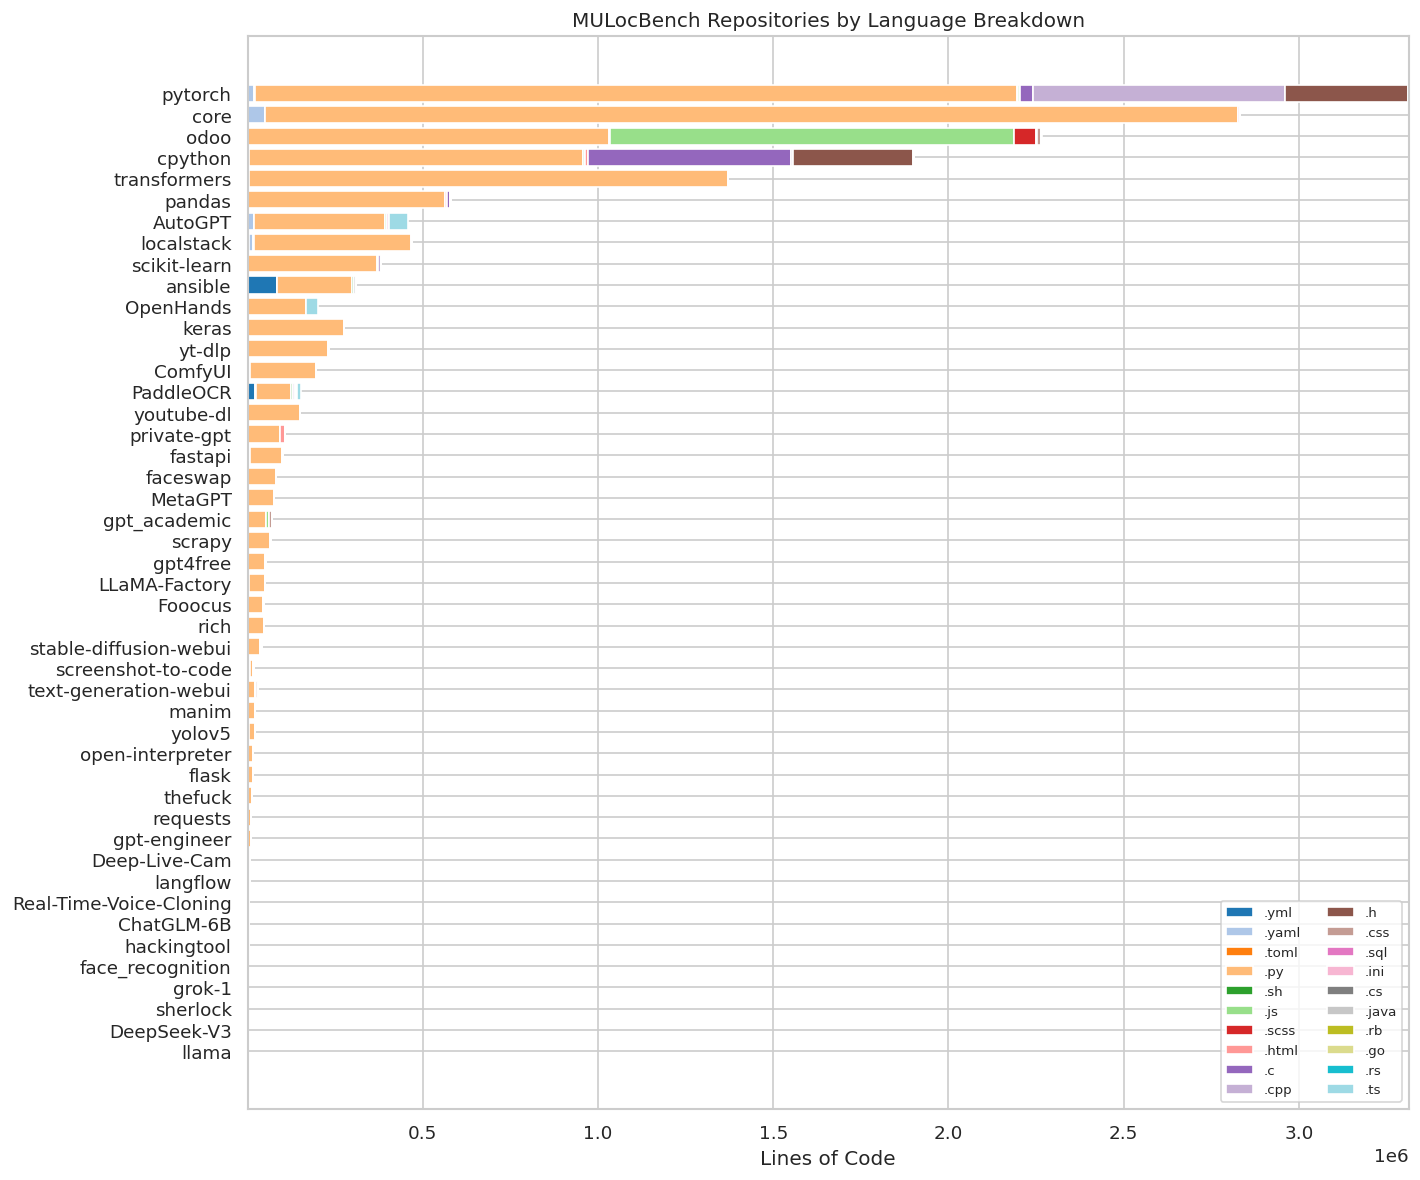

In [61]:
%matplotlib inline
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

with open('loc_by_language.json', 'r') as f:
    loc_by_language = json.load(f)

# build dataframe
df_loc = pd.DataFrame(loc_by_language).T.fillna(0)

# sort by total loc
df_loc['total'] = df_loc.sum(axis=1)
df_loc = df_loc.sort_values('total')
df_loc = df_loc.drop(columns='total')

# assign a colour to each language
languages = df_loc.columns.tolist()
colours = cm.tab20.colors[:len(languages)]

fig, ax = plt.subplots(figsize=(12, 10))

bottom = np.zeros(len(df_loc))
for lang, colour in zip(languages, colours):
    values = df_loc[lang].values
    ax.barh(df_loc.index, values, left=bottom, color=colour, label=lang)
    bottom += values

ax.set_xlabel('Lines of Code')
ax.set_title('MULocBench Repositories by Language Breakdown')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

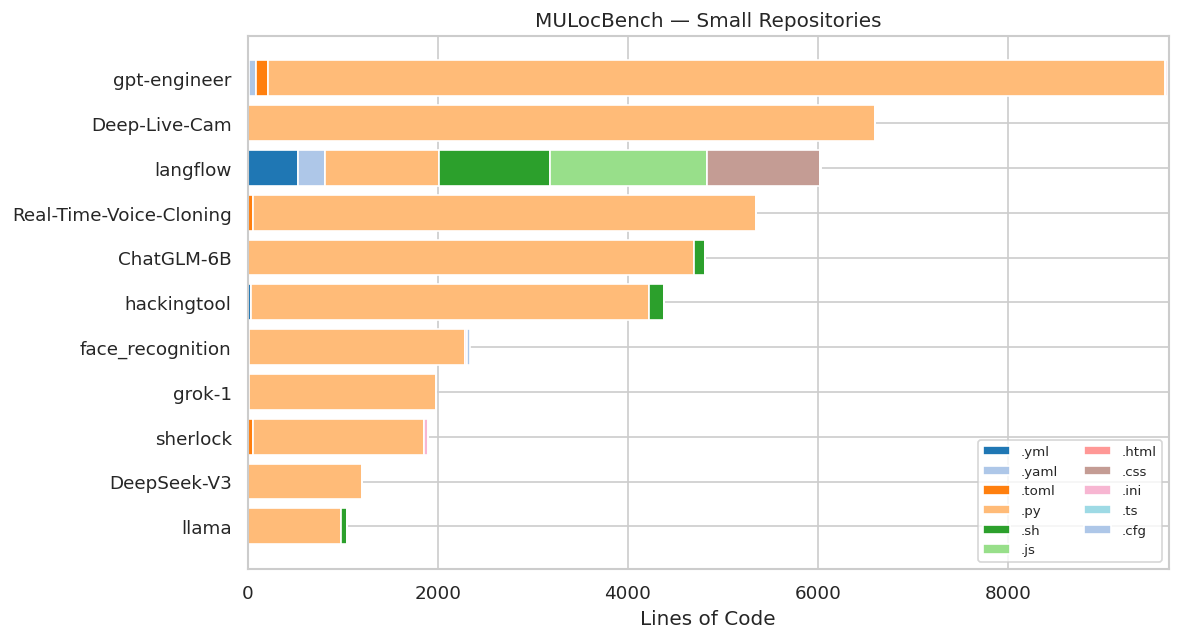

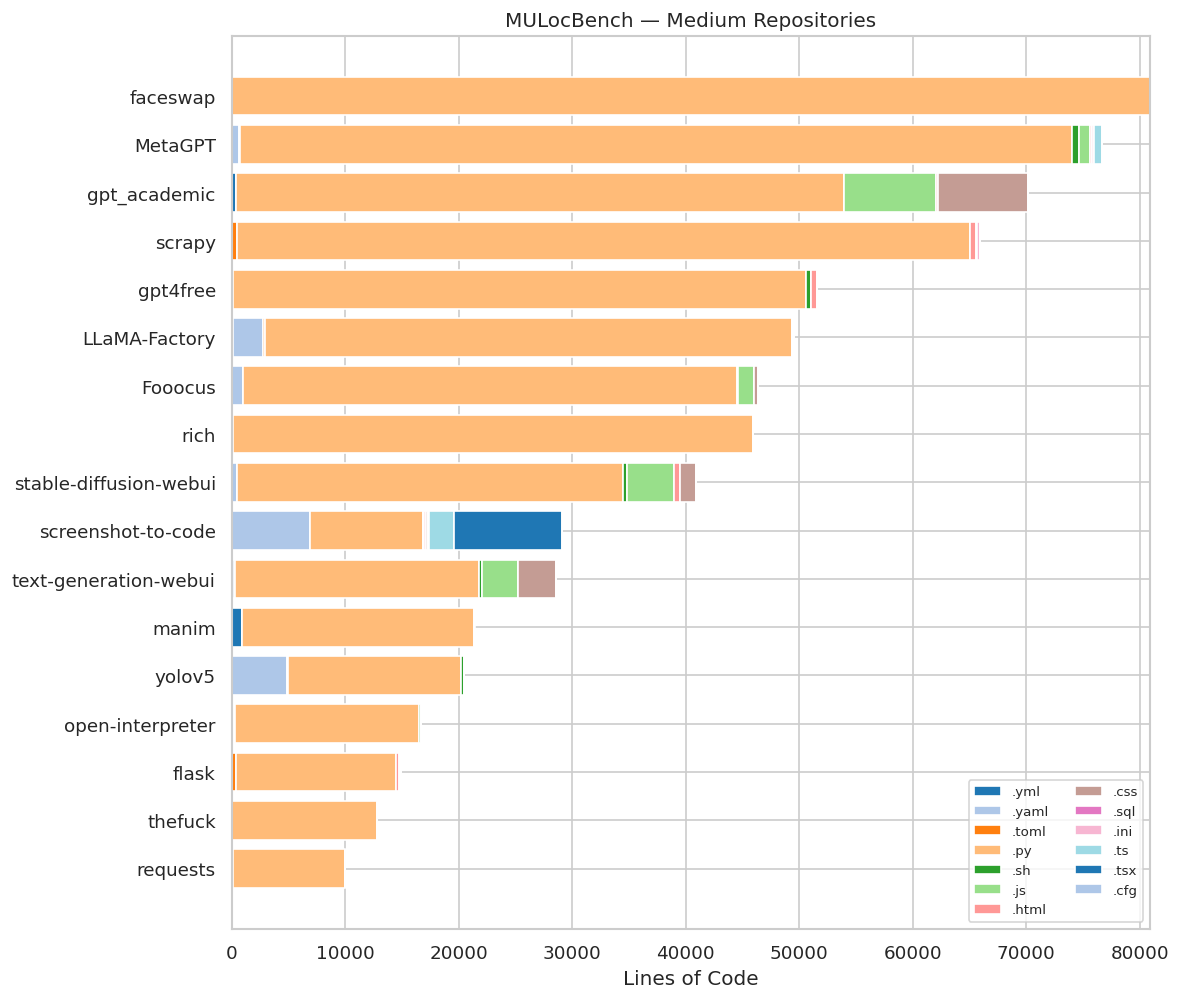

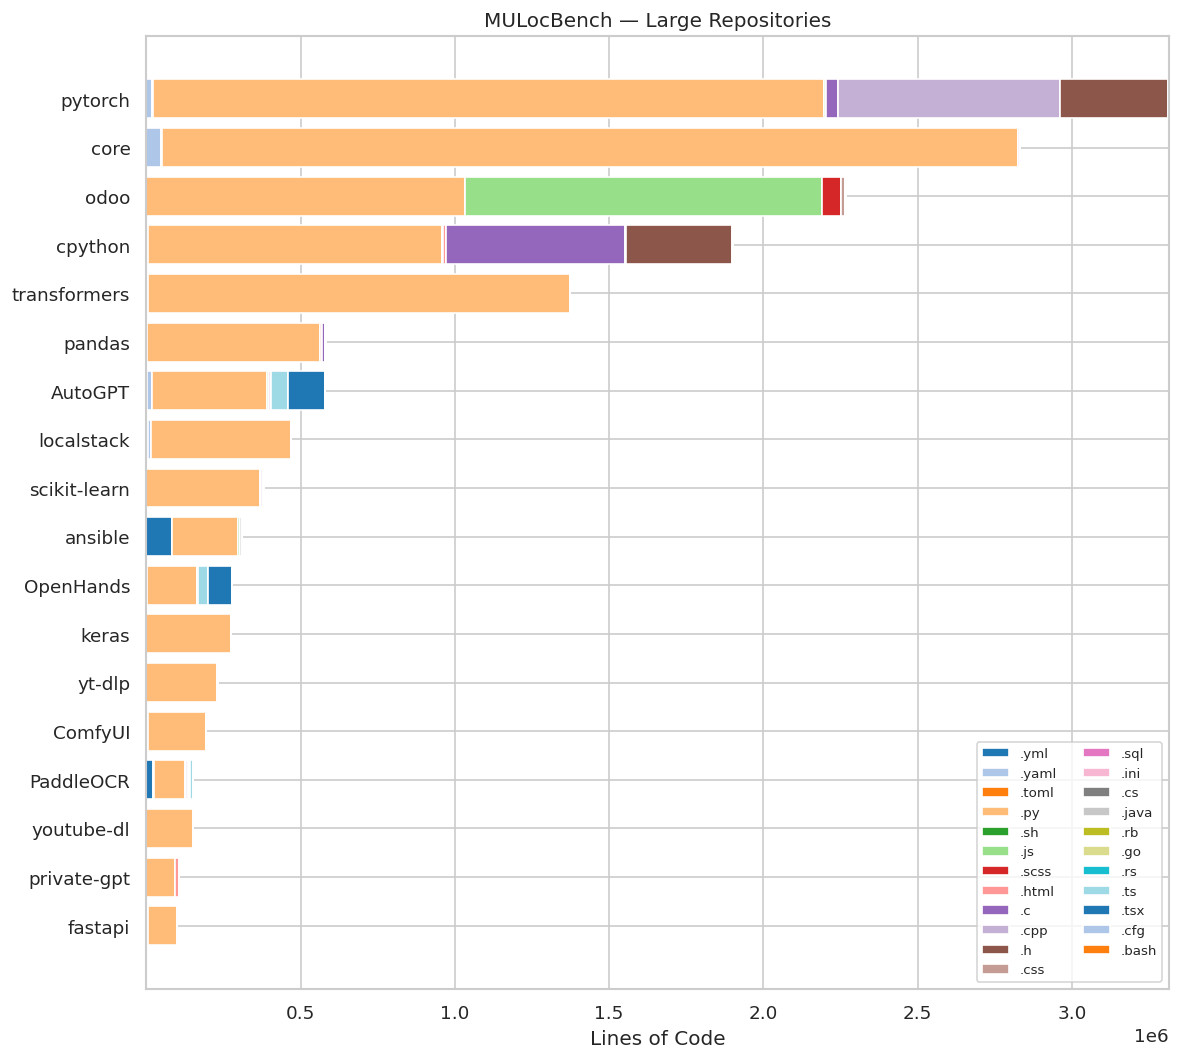

In [62]:
%matplotlib inline
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

with open('loc_by_language.json', 'r') as f:
    loc_by_language = json.load(f)

df_loc = pd.DataFrame(loc_by_language).T.fillna(0)
df_loc['total'] = df_loc.sum(axis=1)
df_loc = df_loc.sort_values('total')

def bucket(total):
    if total < 10000:
        return 'small'
    elif total < 100000:
        return 'medium'
    else:
        return 'large'

df_loc['size'] = df_loc['total'].apply(bucket)
df_loc = df_loc.drop(columns='total')

languages = [c for c in df_loc.columns if c != 'size']
colours = {lang: cm.tab20.colors[i % 20] for i, lang in enumerate(languages)}

for size in ['small', 'medium', 'large']:
    subset = df_loc[df_loc['size'] == size].drop(columns='size')
    
    # drop languages with no entries in this subset
    subset = subset.loc[:, (subset > 0).any()]
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(subset) * 0.5)))
    
    bottom = np.zeros(len(subset))
    for lang in subset.columns:
        values = subset[lang].values
        ax.barh(subset.index, values, left=bottom, 
                color=colours[lang], label=lang)
        bottom += values

    ax.set_xlabel('Lines of Code')
    ax.set_title(f'MULocBench — {size.capitalize()} Repositories')
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

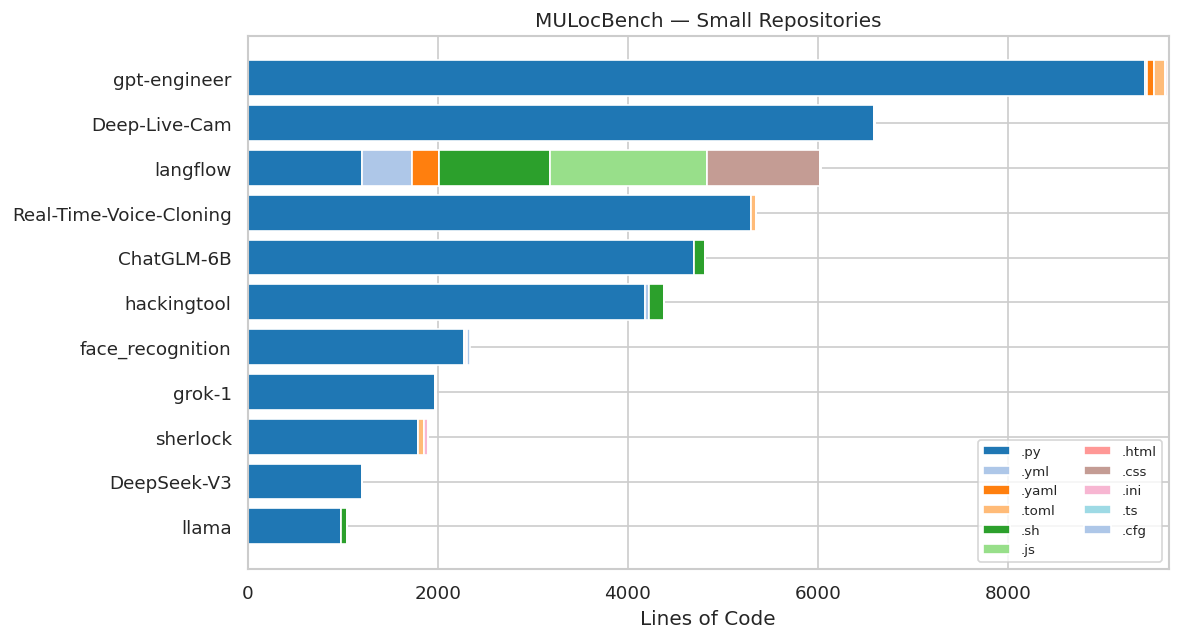

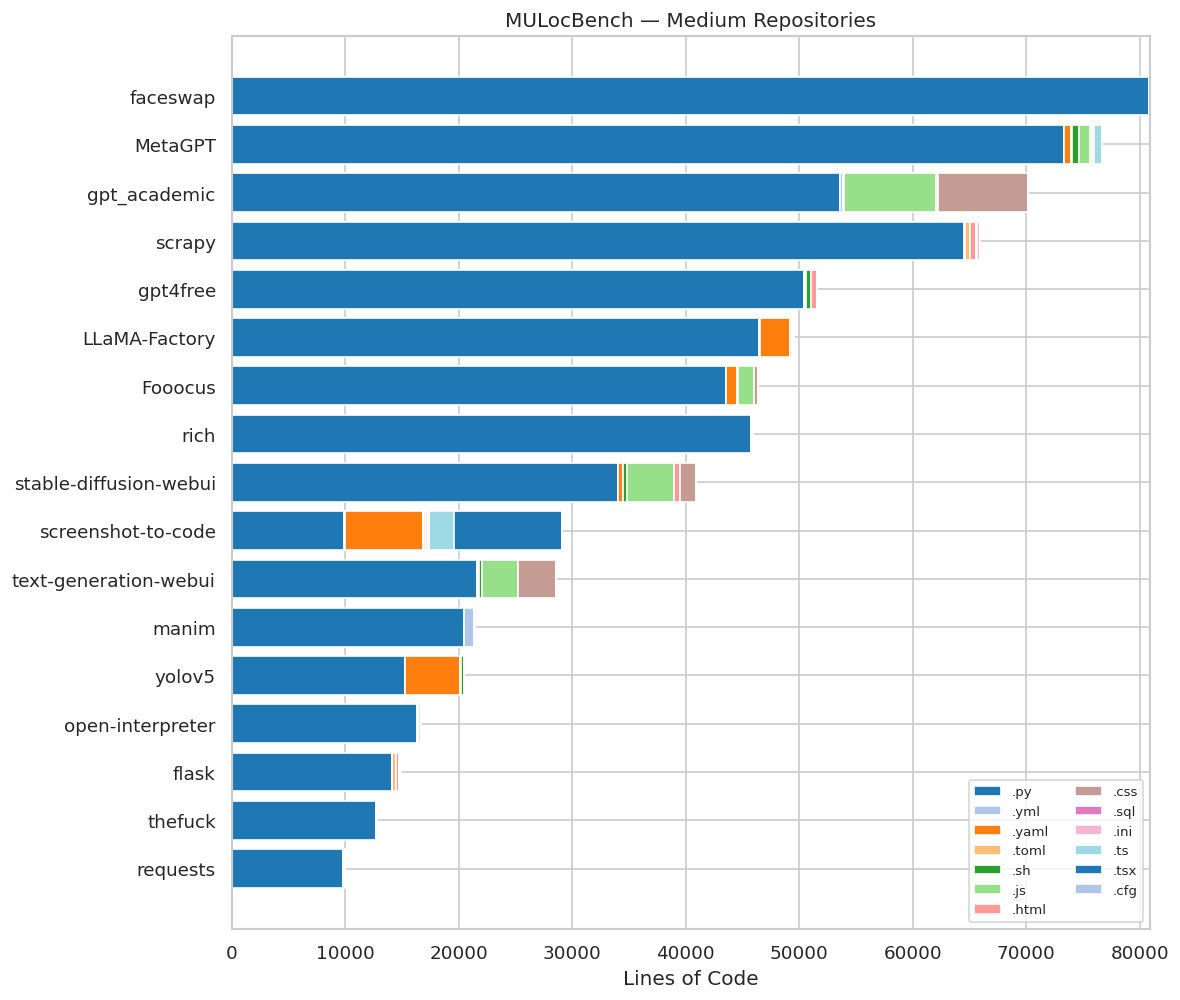

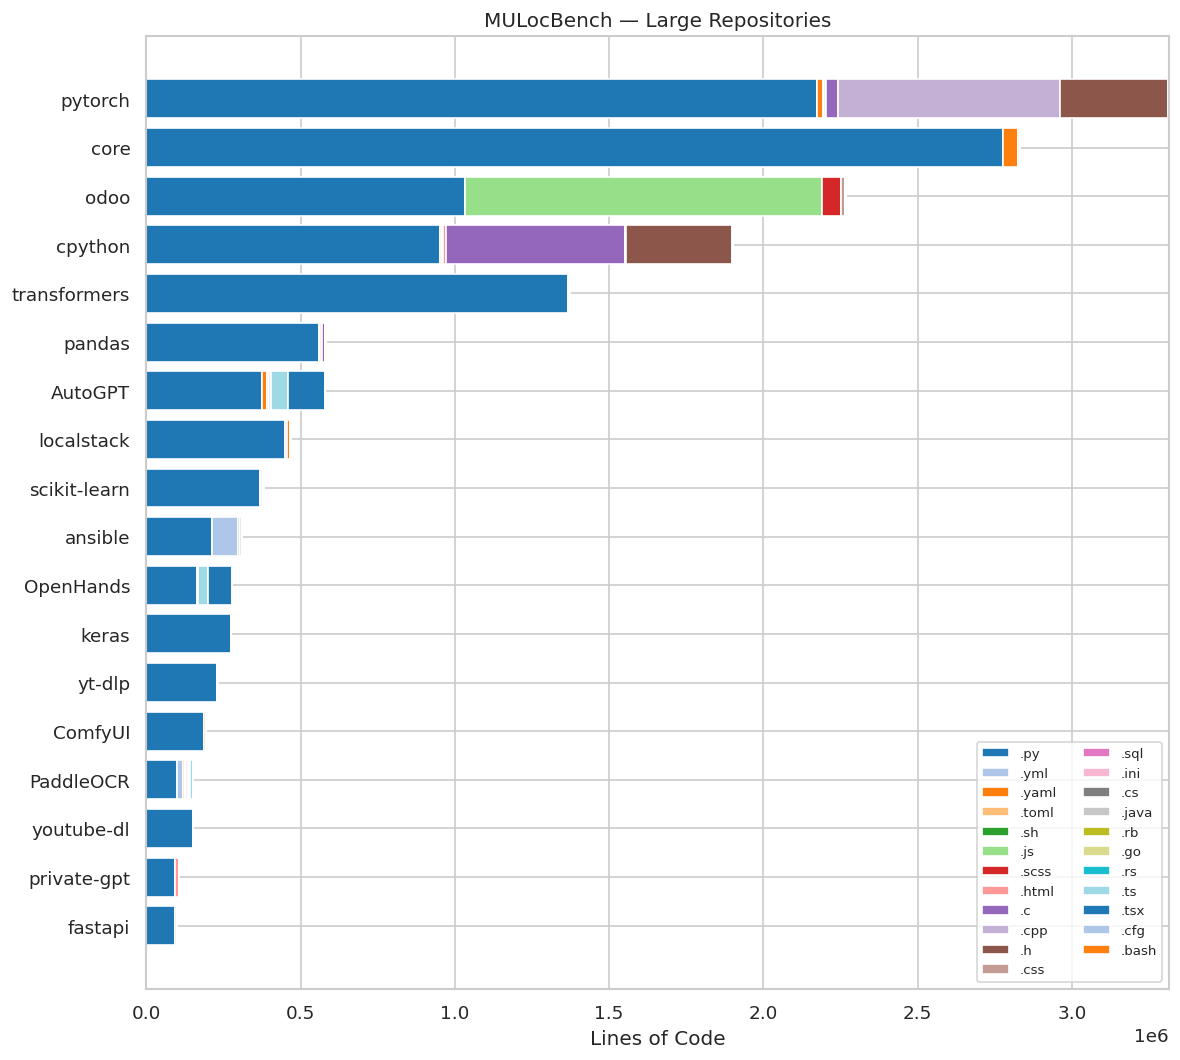

In [63]:
%matplotlib inline
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

with open('loc_by_language.json', 'r') as f:
    loc_by_language = json.load(f)

df_loc = pd.DataFrame(loc_by_language).T.fillna(0)
df_loc['total'] = df_loc.sum(axis=1)
df_loc = df_loc.sort_values('total')

def bucket(total):
    if total < 10000:
        return 'small'
    elif total < 100000:
        return 'medium'
    else:
        return 'large'

df_loc['size'] = df_loc['total'].apply(bucket)
df_loc = df_loc.drop(columns='total')

languages = [c for c in df_loc.columns if c != 'size']

# force .py to the front
languages = ['.py'] + [l for l in languages if l != '.py']

colours = {lang: cm.tab20.colors[i % 20] for i, lang in enumerate(languages)}

for size in ['small', 'medium', 'large']:
    subset = df_loc[df_loc['size'] == size].drop(columns='size')
    subset = subset.loc[:, (subset > 0).any()]
    
    # reorder columns with .py first
    cols = ['.py'] + [c for c in subset.columns if c != '.py']
    subset = subset[cols]

    fig, ax = plt.subplots(figsize=(10, max(4, len(subset) * 0.5)))

    bottom = np.zeros(len(subset))
    for lang in subset.columns:
        values = subset[lang].values
        ax.barh(subset.index, values, left=bottom,
                color=colours[lang], label=lang)
        bottom += values

    ax.set_xlabel('Lines of Code')
    ax.set_title(f'MULocBench — {size.capitalize()} Repositories')
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

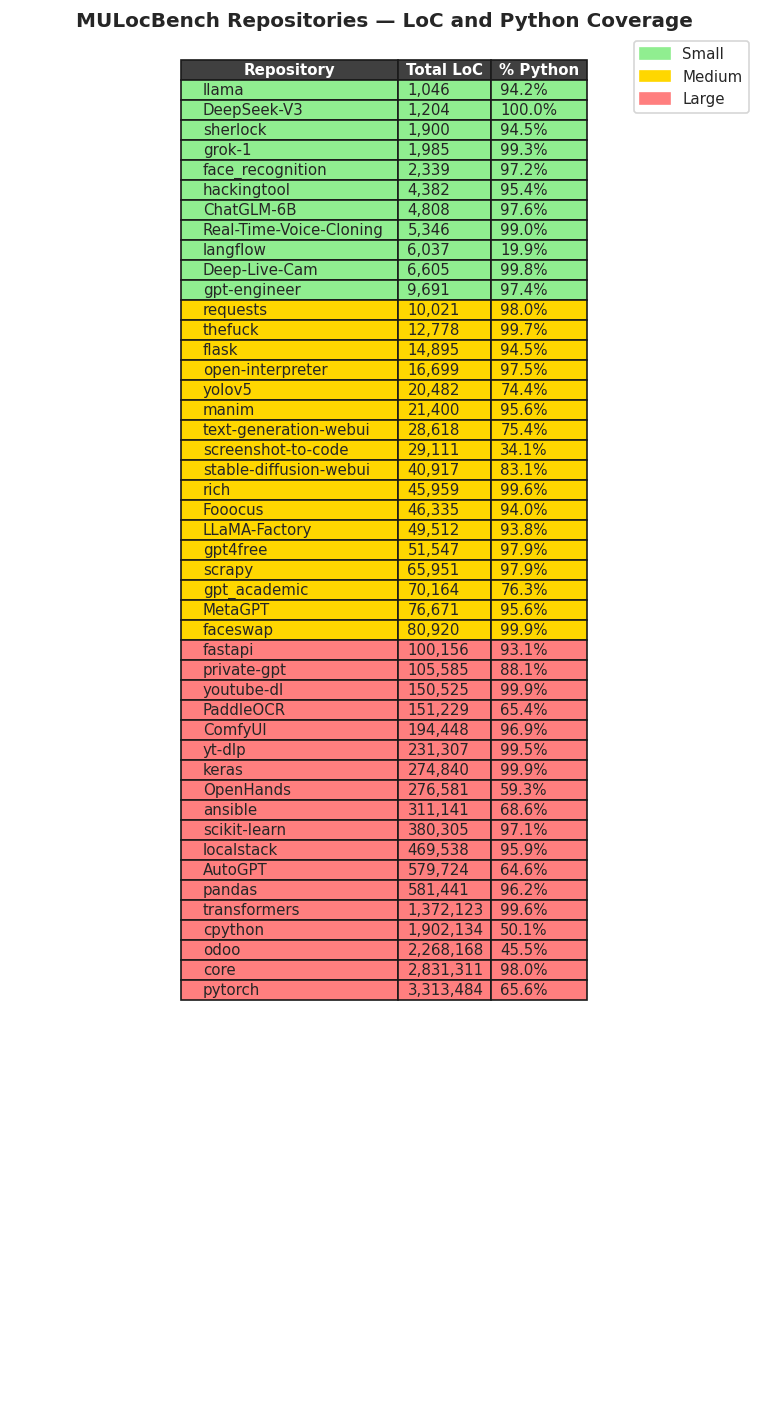

In [64]:
%matplotlib inline
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

with open('loc_by_language.json', 'r') as f:
    loc_by_language = json.load(f)

df_loc = pd.DataFrame(loc_by_language).T.fillna(0)
df_loc['total'] = df_loc.sum(axis=1)
df_loc['pct_python'] = (df_loc.get('.py', 0) / df_loc['total'] * 100).round(1)
df_loc = df_loc[['total', 'pct_python']].sort_values('total')

def bucket(total):
    if total < 10000:
        return 'small'
    elif total < 100000:
        return 'medium'
    else:
        return 'large'

df_loc['size'] = df_loc['total'].apply(bucket)

color_map = {'small': '#90EE90', 'medium': '#FFD700', 'large': '#FF7F7F'}

table_data = [
    [repo, f'{int(row.total):,}', f'{row.pct_python}%']
    for repo, row in df_loc.iterrows()
]

fig, ax = plt.subplots(figsize=(8, len(df_loc) * 0.31 + 0.5))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=['Repository', 'Total LoC', '% Python'],
    loc='upper center',
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width([0, 1, 2])

for i, (repo, row) in enumerate(df_loc.iterrows()):
    colour = color_map[row['size']]
    for j in range(3):
        table[i+1, j].set_facecolor(colour)

for j in range(3):
    table[0, j].set_facecolor('#404040')
    table[0, j].set_text_props(color='white', fontweight='bold')

patches = [mpatches.Patch(color=color_map[s], label=s.capitalize())
           for s in ['small', 'medium', 'large']]
ax.legend(handles=patches, bbox_to_anchor=(1, 1), loc='upper right', fontsize=9)

plt.title('MULocBench Repositories — LoC and Python Coverage',
          fontweight='bold', pad=4)
fig.savefig('loc_python_table.png', dpi=150, bbox_inches='tight', pad_inches=0.2)
plt.show()

In [67]:
import subprocess
import pandas as pd

flask_issues = df[df['repo_name'] == 'flask'].copy()

dates = []
for _, row in flask_issues.iterrows():
    result = subprocess.run(
        ['git', 'log', '-1', '--format=%ci', row['base_commit']],
        capture_output=True, text=True,
        cwd='repos/flask_full'
    )
    dates.append(result.stdout.strip())

flask_issues['commit_date'] = dates
print(flask_issues[['title', 'commit_date']].to_string())


                                                                                                          title                commit_date
1                                                                               Handle app factory in FLASK_APP  2017-05-25 10:46:45 -0700
9                                                                                           Nestable blueprints  2021-04-12 11:47:24 -0700
36                                                           Misspelling in docs @ flask.Flask.handle_exception  2012-09-22 18:50:11 -0700
41                                                               Allow flexible routing with SERVER_NAME config  2024-11-08 09:55:00 -0800
115                                                                                           Remove simplejson  2020-04-04 14:50:21 -0700
208                                                     Returning Response and headers causes duplicate headers  2020-07-23 16:52:52 -0700
233  Flask.auto_find_instan

In [5]:
requests_issues = df[df['repo_name'] == 'requests'].copy().reset_index(drop=True)
for i, row in requests_issues.iterrows():
    print(f"{i}: {row['title']}")
    print(f"   label: {row['iss_label']}")
    print(f"   files: {row['loctype']}")
    print()

0: AttributeError: 'NoneType' object has no attribute 'read'
   label: 
   files: {'code': ['requests/models.py'], 'doc': [], 'test': ['tests/test_requests.py'], 'config': [], 'asset': []}

1: utils.get_netrc_auth silently fails when netrc exists but fails to parse
   label: Feature Request
Contributor Friendly
   files: {'code': ['requests/utils.py'], 'doc': [], 'test': [], 'config': [], 'asset': []}

2: URL proxy auth with empty passwords doesn't emit auth header.
   label: 
   files: {'code': ['requests/adapters.py'], 'doc': [], 'test': ['tests/test_requests.py'], 'config': [], 'asset': []}

3: Create an Extra for Better SSL Support
   label: Planned
Contributor Friendly
   files: {'code': ['setup.py'], 'doc': [], 'test': [], 'config': [], 'asset': []}

4: Requests doesn't catch requests.packages.urllib3.exceptions.ProxyError
   label: 
   files: {'code': ['requests/adapters.py', 'requests/exceptions.py'], 'doc': [], 'test': [], 'config': [], 'asset': []}

5: Session pickling suppor

## Selected MULocBench Tasks — requests

### Primary Tasks (core experiment)

| idx | Title | Target Files | Notes |
|-----|-------|-------------|-------|
| 0 | AttributeError: NoneType object has no attribute read | `requests/models.py` | Single file, clean bug |
| 4 | Requests doesn't catch ProxyError | `requests/adapters.py`, `requests/exceptions.py` | Two files, multi-file localisation |
| 12 | Not possible to specify max_retries in v1.X | `requests/sessions.py`, `requests/adapters.py`, `requests/api.py` | Three files, hardest task |
| 14 | Authentication Handlers lost on redirect | `requests/auth.py` | Single file, different module |
| 15 | Add header name to InvalidHeader exception message | `requests/utils.py`, `HISTORY.rst` | Includes doc file, non-code localisation |

### Backup Tasks

| idx | Title | Target Files | Notes |
|-----|-------|-------------|-------|
| 2 | URL proxy auth with empty passwords | `requests/adapters.py` | Different adapters issue |
| 5 | Session pickling support broken | `requests/sessions.py` | Different sessions issue |
| 10 | Json supersedes data in prepare_body | `requests/models.py` | Different models issue |
| 13 | Problem with missing cookies after redirect | `requests/sessions.py` | Cookie and redirect logic |
| 17 | Doesn't recognize unicode filenames for uploads | `requests/utils.py`, `requests/compat.py` | Covers compat module |

In [6]:
import json

with open('loc_by_language.json', 'r') as f:
    loc_by_language = json.load(f)

requests_langs = loc_by_language.get('requests', {})
total = sum(requests_langs.values())

for lang, count in sorted(requests_langs.items(), key=lambda x: -x[1]):
    pct = count / total * 100
    print(f'{lang}: {count:,} lines ({pct:.1f}%)')

.py: 9,818 lines (98.0%)
.toml: 110 lines (1.1%)
.yaml: 44 lines (0.4%)
.html: 26 lines (0.3%)
.ini: 15 lines (0.1%)
.css: 8 lines (0.1%)


In [20]:
import json
import os

MAPS_DIR = "repo_maps/requests"
TASK_INDICES = [0, 4, 12, 14, 15]

summary = []

for idx in TASK_INDICES:
    task_dir = os.path.join(MAPS_DIR, f"task_{idx}")
    ast_path = os.path.join(task_dir, "ast_map.json")
    ctags_path = os.path.join(task_dir, "ctags_map.json")

    with open(ast_path, encoding="utf-8") as f:
        ast_chars = sum(len(line) for line in f)
    with open(ctags_path, encoding="utf-8") as f:
        ctags_chars = sum(len(line) for line in f)

    ast_tokens = ast_chars // 4
    ctags_tokens = ctags_chars // 4

    summary.append({
        "idx": idx,
        "ast_tokens": ast_tokens,
        "ctags_tokens": ctags_tokens,
    })

col_w = [6, 12, 14]
header = f"{'idx':<{col_w[0]}}{'ast tokens':>{col_w[1]}}{'ctags tokens':>{col_w[2]}}"
sep = "-" * sum(col_w)
print(sep)
print(header)
print(sep)
for row in summary:
    print(
        f"{row['idx']:<{col_w[0]}}"
        f"{row['ast_tokens']:>{col_w[1]},}"
        f"{row['ctags_tokens']:>{col_w[2]},}"
    )
print(sep)

--------------------------------
idx     ast tokens  ctags tokens
--------------------------------
0           10,328        14,165
4            8,716        12,018
12           8,139        11,253
14          10,377        14,215
15          10,879        14,831
--------------------------------


In [16]:
import subprocess

REPO_DIR = "repos/requests_full"
tasks = {0: "ccabcf1f", 4: "9968a10f", 12: "be62645d", 14: "4683f169", 15: "1c2022cf"}

for idx, commit in tasks.items():
    result = subprocess.run(
        ['git', '-C', REPO_DIR, 'show', '-s', '--format=%ci', commit],
        capture_output=True, text=True
    )
    print(f"task {idx} ({commit}): {result.stdout.strip()}")

task 0 (ccabcf1f): 2016-11-23 10:17:31 +0000
task 4 (9968a10f): 2013-09-25 14:00:17 +0100
task 12 (be62645d): 2013-02-25 09:29:05 -0500
task 14 (4683f169): 2016-12-09 14:48:42 +0000
task 15 (1c2022cf): 2017-08-10 14:03:36 -0400


In [21]:
import json

task_dir = "repo_maps/requests/task_15"

with open(f"{task_dir}/ast_map.json") as f:
    ast_records = [json.loads(l) for l in f if l.strip()]

with open(f"{task_dir}/ctags_map.json") as f:
    ctags_records = [json.loads(l) for l in f if l.strip()]

print(f"AST records: {len(ast_records)}")
print(f"ctags records: {len(ctags_records)}")

ast_files = set(r['file'] for r in ast_records)
ctags_files = set(r['path'] for r in ctags_records)

print(f"\nAST unique files: {len(ast_files)}")
for f in sorted(ast_files):
    print(f"  {f}")

print(f"\nctags unique files: {len(ctags_files)}")
for f in sorted(ctags_files):
    print(f"  {f}")

AST records: 264
ctags records: 266

AST unique files: 13
  requests/__init__.py
  requests/_internal_utils.py
  requests/adapters.py
  requests/api.py
  requests/auth.py
  requests/cookies.py
  requests/exceptions.py
  requests/help.py
  requests/hooks.py
  requests/models.py
  requests/sessions.py
  requests/structures.py
  requests/utils.py

ctags unique files: 13
  repos/requests_full/requests/__init__.py
  repos/requests_full/requests/_internal_utils.py
  repos/requests_full/requests/adapters.py
  repos/requests_full/requests/api.py
  repos/requests_full/requests/auth.py
  repos/requests_full/requests/cookies.py
  repos/requests_full/requests/exceptions.py
  repos/requests_full/requests/help.py
  repos/requests_full/requests/hooks.py
  repos/requests_full/requests/models.py
  repos/requests_full/requests/sessions.py
  repos/requests_full/requests/structures.py
  repos/requests_full/requests/utils.py


In [18]:
from collections import Counter

for task_idx in [0, 15]:
    task_dir = f"repo_maps/requests/task_{task_idx}"
    with open(f"{task_dir}/ctags_map.json") as f:
        records = [json.loads(l) for l in f if l.strip()]
    
    counts = Counter(r['path'].split('requests_full/')[-1] for r in records)
    print(f"\n--- task {task_idx} ---")
    for path, count in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {path}: {count}")
        


--- task 0 ---
  requests/packages/urllib3/packages/six.py: 67
  requests/cookies.py: 52
  requests/models.py: 45
  requests/packages/urllib3/exceptions.py: 44
  requests/packages/urllib3/response.py: 36
  requests/utils.py: 35
  requests/packages/urllib3/_collections.py: 34
  requests/packages/urllib3/contrib/pyopenssl.py: 32
  requests/sessions.py: 28
  requests/packages/urllib3/connectionpool.py: 27
  requests/packages/urllib3/packages/ordered_dict.py: 26
  requests/packages/chardet/chardistribution.py: 25
  requests/auth.py: 22
  requests/exceptions.py: 22
  requests/packages/idna/core.py: 22
  requests/adapters.py: 19
  requests/packages/urllib3/poolmanager.py: 18
  requests/packages/urllib3/connection.py: 16
  requests/structures.py: 16
  requests/packages/urllib3/util/retry.py: 16
  requests/packages/urllib3/contrib/appengine.py: 15
  requests/packages/chardet/jpcntx.py: 13
  requests/packages/urllib3/util/ssl_.py: 12
  requests/packages/urllib3/util/timeout.py: 11
  requests/p

In [22]:
from collections import Counter

for task_idx in [0, 15]:
    task_dir = f"repo_maps/requests/task_{task_idx}"
    with open(f"{task_dir}/ast_map.json") as f:
        records = [json.loads(l) for l in f if l.strip()]
    
    counts = Counter(r['file'] for r in records)
    print(f"\n--- task {task_idx} (AST) ---")
    for path, count in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {path}: {count}")


--- task 0 (AST) ---
  requests/cookies.py: 52
  requests/models.py: 45
  requests/utils.py: 34
  requests/sessions.py: 28
  requests/exceptions.py: 22
  requests/auth.py: 21
  requests/adapters.py: 19
  requests/structures.py: 16
  requests/api.py: 8
  requests/__init__.py: 2
  requests/hooks.py: 2
  requests/_internal_utils.py: 1
  requests/certs.py: 1

--- task 15 (AST) ---
  requests/cookies.py: 52
  requests/models.py: 49
  requests/utils.py: 37
  requests/sessions.py: 29
  requests/exceptions.py: 23
  requests/auth.py: 21
  requests/adapters.py: 19
  requests/structures.py: 16
  requests/api.py: 8
  requests/__init__.py: 3
  requests/help.py: 3
  requests/_internal_utils.py: 2
  requests/hooks.py: 2
